# Project: Data-driven Insights using Python: FoodHub Data Analysis



# Problem Statement

## Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. An online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub, offers access to multiple restaurants through a single smartphone app.
The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirm the pick-up in the app and travel to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.



## Objective

The food aggregator company has stored the data of the different orders made by the registered customers in its online portal. They want to analyze the data to get a fair idea about the demand for different restaurants, which will help them enhance their customer experience. Suppose you are hired as a Data Scientist in this company, and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

## Data Description

The data contains different data related to a food order. The detailed data dictionary is given below.

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

# Let us start by importing the required libraries

In [285]:
# Installing the libraries with the specified version.
#!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

#This code throws an error from a subprocess, so I am commenting it out
#I am going to import the libraries directly

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [286]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Understanding the structure of the data

In [287]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [288]:
# Write your code here to read the data
path = "/content/drive/MyDrive/UT DS Grad Cert/Project1/"
food = pd.read_csv(path + "foodhub_order.csv")

In [289]:
# Write your code here to view the first 5 rows
food.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.750,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.080,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.230,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.590,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [290]:
# This provides the number of rows and columns in the data
food.shape

(1898, 9)

#### Observations: There are 1898 rows (observations) across 9 columns (variables).


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [291]:
# This describes the type of data we have
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: The data contains 4 columns with string data: 1) Restaurant Name, 2) Cuisine Type, 3) Day of the Week, and 4) Rating.  From the header, rating is listed as string since the phrase "not given" is present for missing numeric ratings.  Four of the columns contain integer values: 1) Order ID, 2) Customer ID, 3) Food Preperation Time, and 3) Delivery time.  Finally, there is one float variable for Cost of the Order.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [292]:
#This uses boolean logic and then sums all the true values for where data is null
food.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:  There are no missing values in this dataframe.  By checking the dataframe with the .isnull() method, a boolean dataframe of the same shape was returned.  Summing this dataframe interprets true as 1 and false as 0.  Thus a sum of 0 for each category shows there were no "true" or missing values.


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [293]:
#setting the .describe display to default to float rather than scientific notation
pd.set_option('display.float_format', '{:,.3f}'.format)

food.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,"1,898.000","1,477,495.500",548.050,"1,476,547.000","1,477,021.250","1,477,495.500","1,477,969.750","1,478,444.000"
customer_id,"1,898.000","171,168.478","113,698.140","1,311.000","77,787.750","128,600.000","270,525.000","405,334.000"
cost_of_the_order,"1,898.000",16.499,7.484,4.470,12.080,14.140,22.297,35.410
food_preparation_time,"1,898.000",27.372,4.632,20.000,23.000,27.000,31.000,35.000
delivery_time,"1,898.000",24.162,4.973,15.000,20.000,25.000,28.000,33.000


In [294]:
#This gives a numeric summary of the food preparation time variable
food['food_preparation_time'].describe()

,food_preparation_time
count,"1,898.000"
mean,27.372
std,4.632
min,20.000
25%,23.000
50%,27.000
75%,31.000
max,35.000


#### Observations:  Across all restaurants (n=1898), the food takes an average of 27.372 minutes to be prepared.  The median of this dataset is 27 min.  The minimum reported prep time is 20 minutes, while the maximum reported time is 35 minutes.  An eyeball view of the numbers suggests a normal distribution of the data; however, this will need to be verified with a histogram and/or bloxplot.


### **Question 5:** How many orders are not rated? [1 mark]

In [295]:
# This totals all the unique values in the ratings column
food['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


#### Observations: From the summary table above, 736 orders were not rated by customers.


# Exploratory Data Analysis (EDA)

## Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [296]:
# The code below creates a list of the categorical and numerical columns for easier analysis
cat_columns = [columns for columns in food.columns if food[columns].dtype == 'object']
num_columns = [columns for columns in food.columns if food[columns].dtype != 'object']

#Check for how many of each there are
print(len(cat_columns))
print(len(num_columns))

4
5


###Numeric Plots

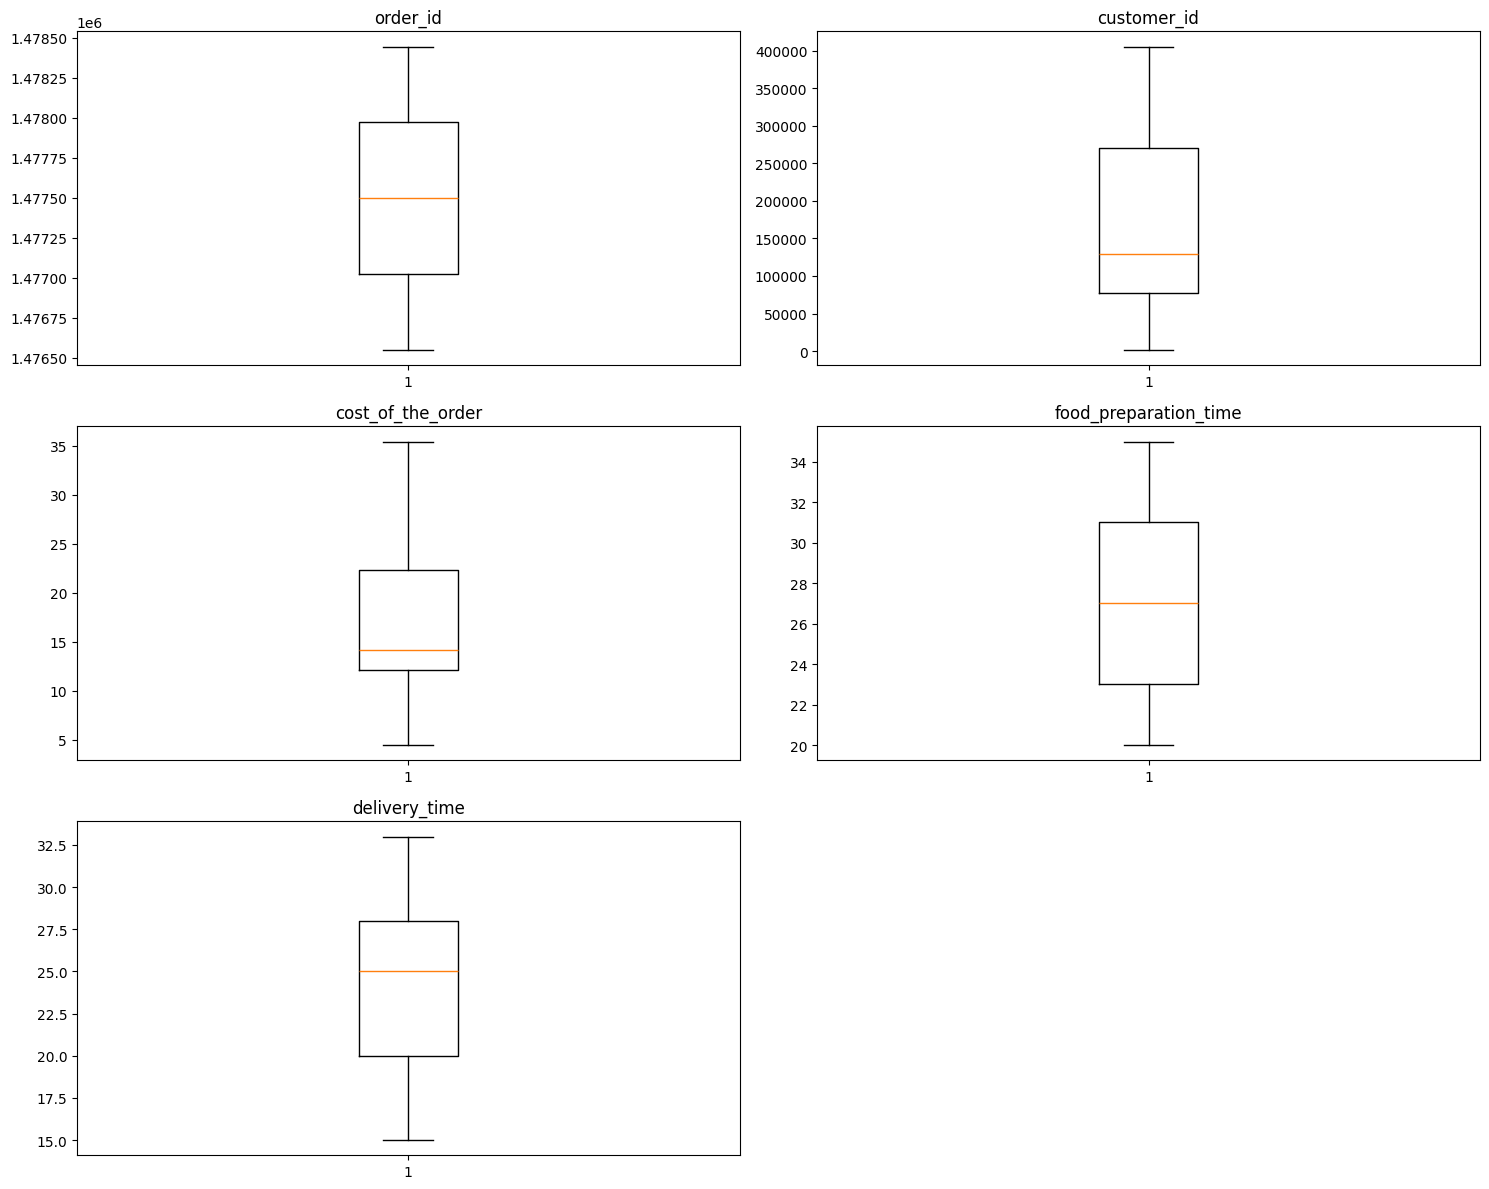

In [297]:
#set the size of the plot area for easier readability
plt.figure(figsize=(15, 12))

#looping through each of the numeric columns and creating a separate boxplot for each
for i, variable in enumerate(num_columns):
    plt.subplot(3, 2, i + 1)
    plt.boxplot(food[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

####Observations:
The five numeric columns are order_id, customer_id, cost_of_the_order, food_prep_time and food_delivery_time.  Of these, order_id and customer_id should really be treated as categorical since they merely identify the customer or the order in the system.  Any numerical analysis of these variables would be inconclusive.

Of the remaining three columns, food prep time and food delivery time are both approxiamately normally distributed.  The cost of the order is right skewed; however, there are no substantial outliers (as defined by Q3 + 1.5*IQR).  Histograms will be generated for each of these plots below.

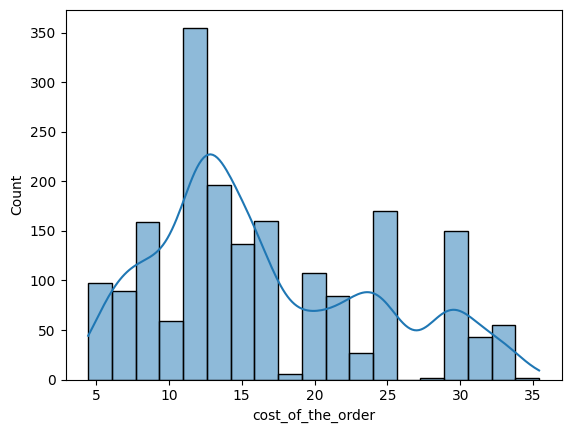

,cost_of_the_order
count,"1,898.000"
mean,16.499
std,7.484
min,4.470
25%,12.080
50%,14.140
75%,22.297
max,35.410


In [298]:
# create a histogram for the cost of the order
sns.histplot(data=food, x = 'cost_of_the_order', kde = True)
plt.show()
food['cost_of_the_order'].describe()

####Observations:
As seen above, the cost of food is right skewed with 50% of the cost being between \$12.08 and \$22.30. However, the top 25% of food costs ranges \$17 above this mark, while the lower 25% of the food only ranges \$8. Oddly, and possibly worth exploring further, there seems to be almost no charges in the \$25 -\$30 range, which seems odd for a data set of this size.

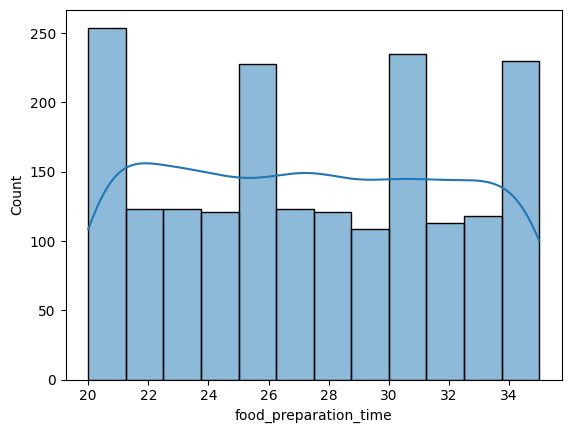

0    21
Name: food_preparation_time, dtype: int64


In [299]:
#Histogram for food prep time
sns.histplot(data=food, x = 'food_preparation_time', kde = True)
plt.show()
modes = food['food_preparation_time'].mode()
print(modes)


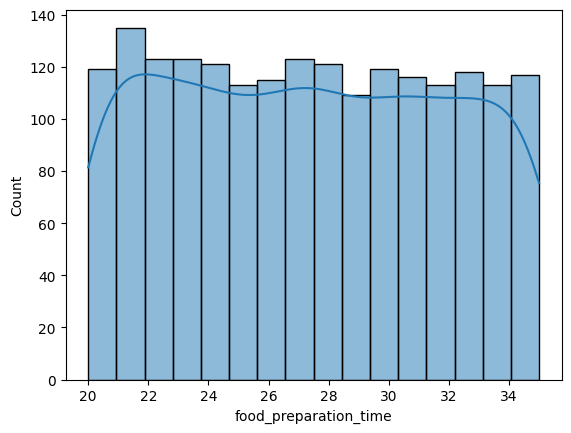

,food_preparation_time
count,"1,898.000"
mean,27.372
std,4.632
min,20.000
25%,23.000
50%,27.000
75%,31.000
max,35.000


In [300]:
#Add a few more bins to the default size
sns.histplot(data=food, x = 'food_preparation_time', kde = True, bins = 16)
plt.show()

#printing the numeric summary of the variable
food['food_preparation_time'].describe()


####Observations:
Unlike what the boxplot suggested, food prep time is approximately uniformly distributed.  While the mode of the data set is 21, after adjusting the number of bins, we can see that the distribution is uniform with no clear peaks.  Food was prepared at a mean of 27.372 minutes and a standard deviation of 4.632 minutes.

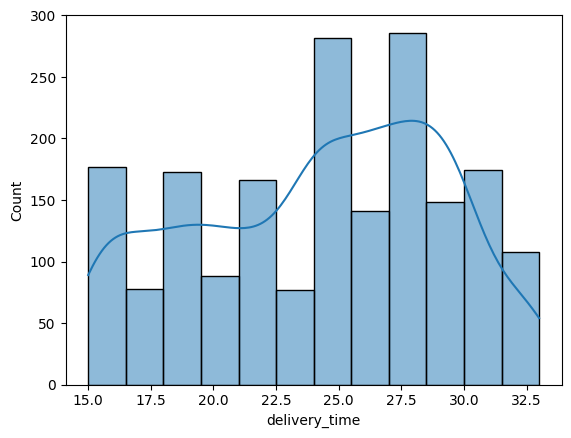

,delivery_time
count,"1,898.000"
mean,24.162
std,4.973
min,15.000
25%,20.000
50%,25.000
75%,28.000
max,33.000


In [301]:
#histogram for delivery time and its numeric summary
sns.histplot(data=food, x = 'delivery_time', kde = True, bins = 12)
plt.show()
food['delivery_time'].describe()

####Observations:
Delivery time for the food orders is either slightly left skewed or approximately normal.  I altered the bin numbers a bit from the default in pandas to see if a clearer trend would emerge, but none did.  Orders were delivered at a mean of 24.162 minutes and a standard deviation of 4.973 minutes.

###Categorical Plots

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


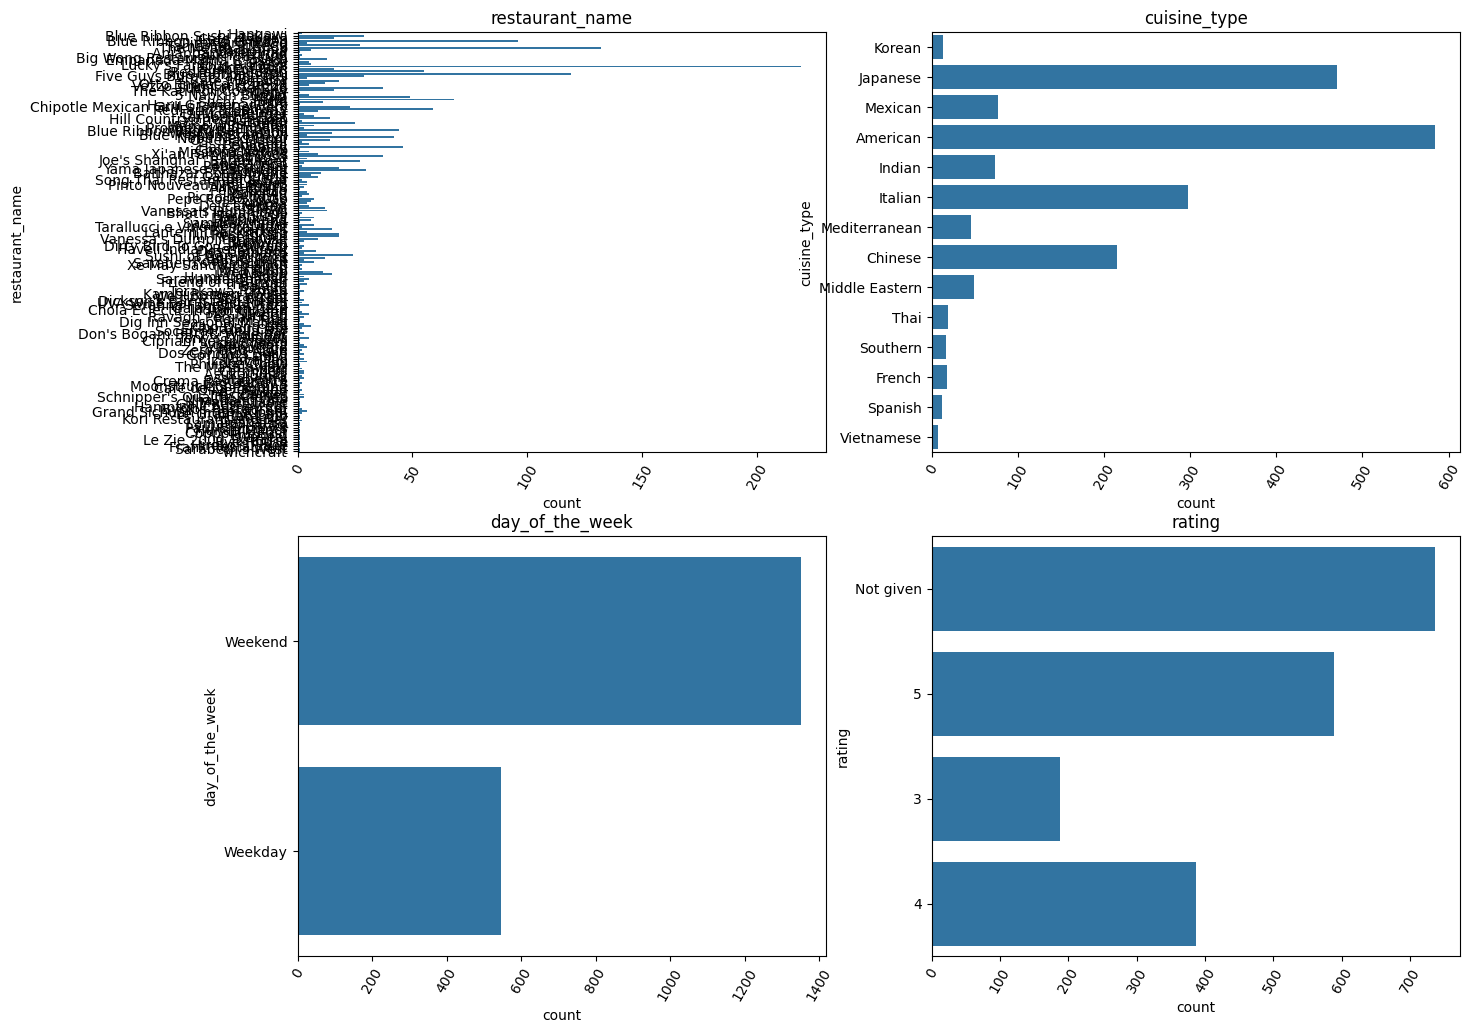

In [302]:
#set plot area
plt.figure(figsize=(15, 12))

#loop through all categorical plots and create a bargraph for each variable
for i, column in enumerate(cat_columns):
    plt.subplot(2, 2, i + 1)
    sns.countplot(food[column])
    plt.xticks(rotation = 60)
    plt.title(column)

plt.show()

#The warning below indicates that some of the restaurant names have characters or fonts not supported by the one
# loaded in Google Colab.  I am not sure how to resolve this.

####Observations:
From a high level standpoint, restaurant names will need to be dealt with separately since so many restaurants were chosen.  Overall, weekends were more than twice as popular times to order food as were weekdays.  The four most popular types of food to order were American, Japanese, Italian, and Chinese.  The most popular rating was a five out of five, closely followed by a four.  However, no rating given was actually the most common occurence.

In [303]:
#The code below creates normalized counts of the thre main categorical variables
# restaurant names were excluded due to high volume of items
weekend_per = food['day_of_the_week'].value_counts(normalize=True)
print(weekend_per)
cuisine_per = food['cuisine_type'].value_counts(normalize=True)
print(cuisine_per)
ratings_per = food['rating'].value_counts(normalize=True)
print(ratings_per)

#calculate proportion of top 4 cuisine types
print(np.sum(0.308+0.248+0.157+0.113))

day_of_the_week
Weekend   0.712
Weekday   0.288
Name: proportion, dtype: float64
cuisine_type
American         0.308
Japanese         0.248
Italian          0.157
Chinese          0.113
Mexican          0.041
Indian           0.038
Middle Eastern   0.026
Mediterranean    0.024
Thai             0.010
French           0.009
Southern         0.009
Korean           0.007
Spanish          0.006
Vietnamese       0.004
Name: proportion, dtype: float64
rating
Not given   0.388
5           0.310
4           0.203
3           0.099
Name: proportion, dtype: float64
0.8260000000000001


####Observations
- Weekends account for 70% of business.
- The four most popular cuisine types (American, Japanese, Italian, and Chinese) account for 82.6% of orders, while French, Souther, Korean, Spanish, and Vietnamese account for less than 1% of orders combined.
- 38.8% of orders went unrated (the highest single category). This could lead to skewed data.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 140 (\x8c) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 142 (\x8e) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


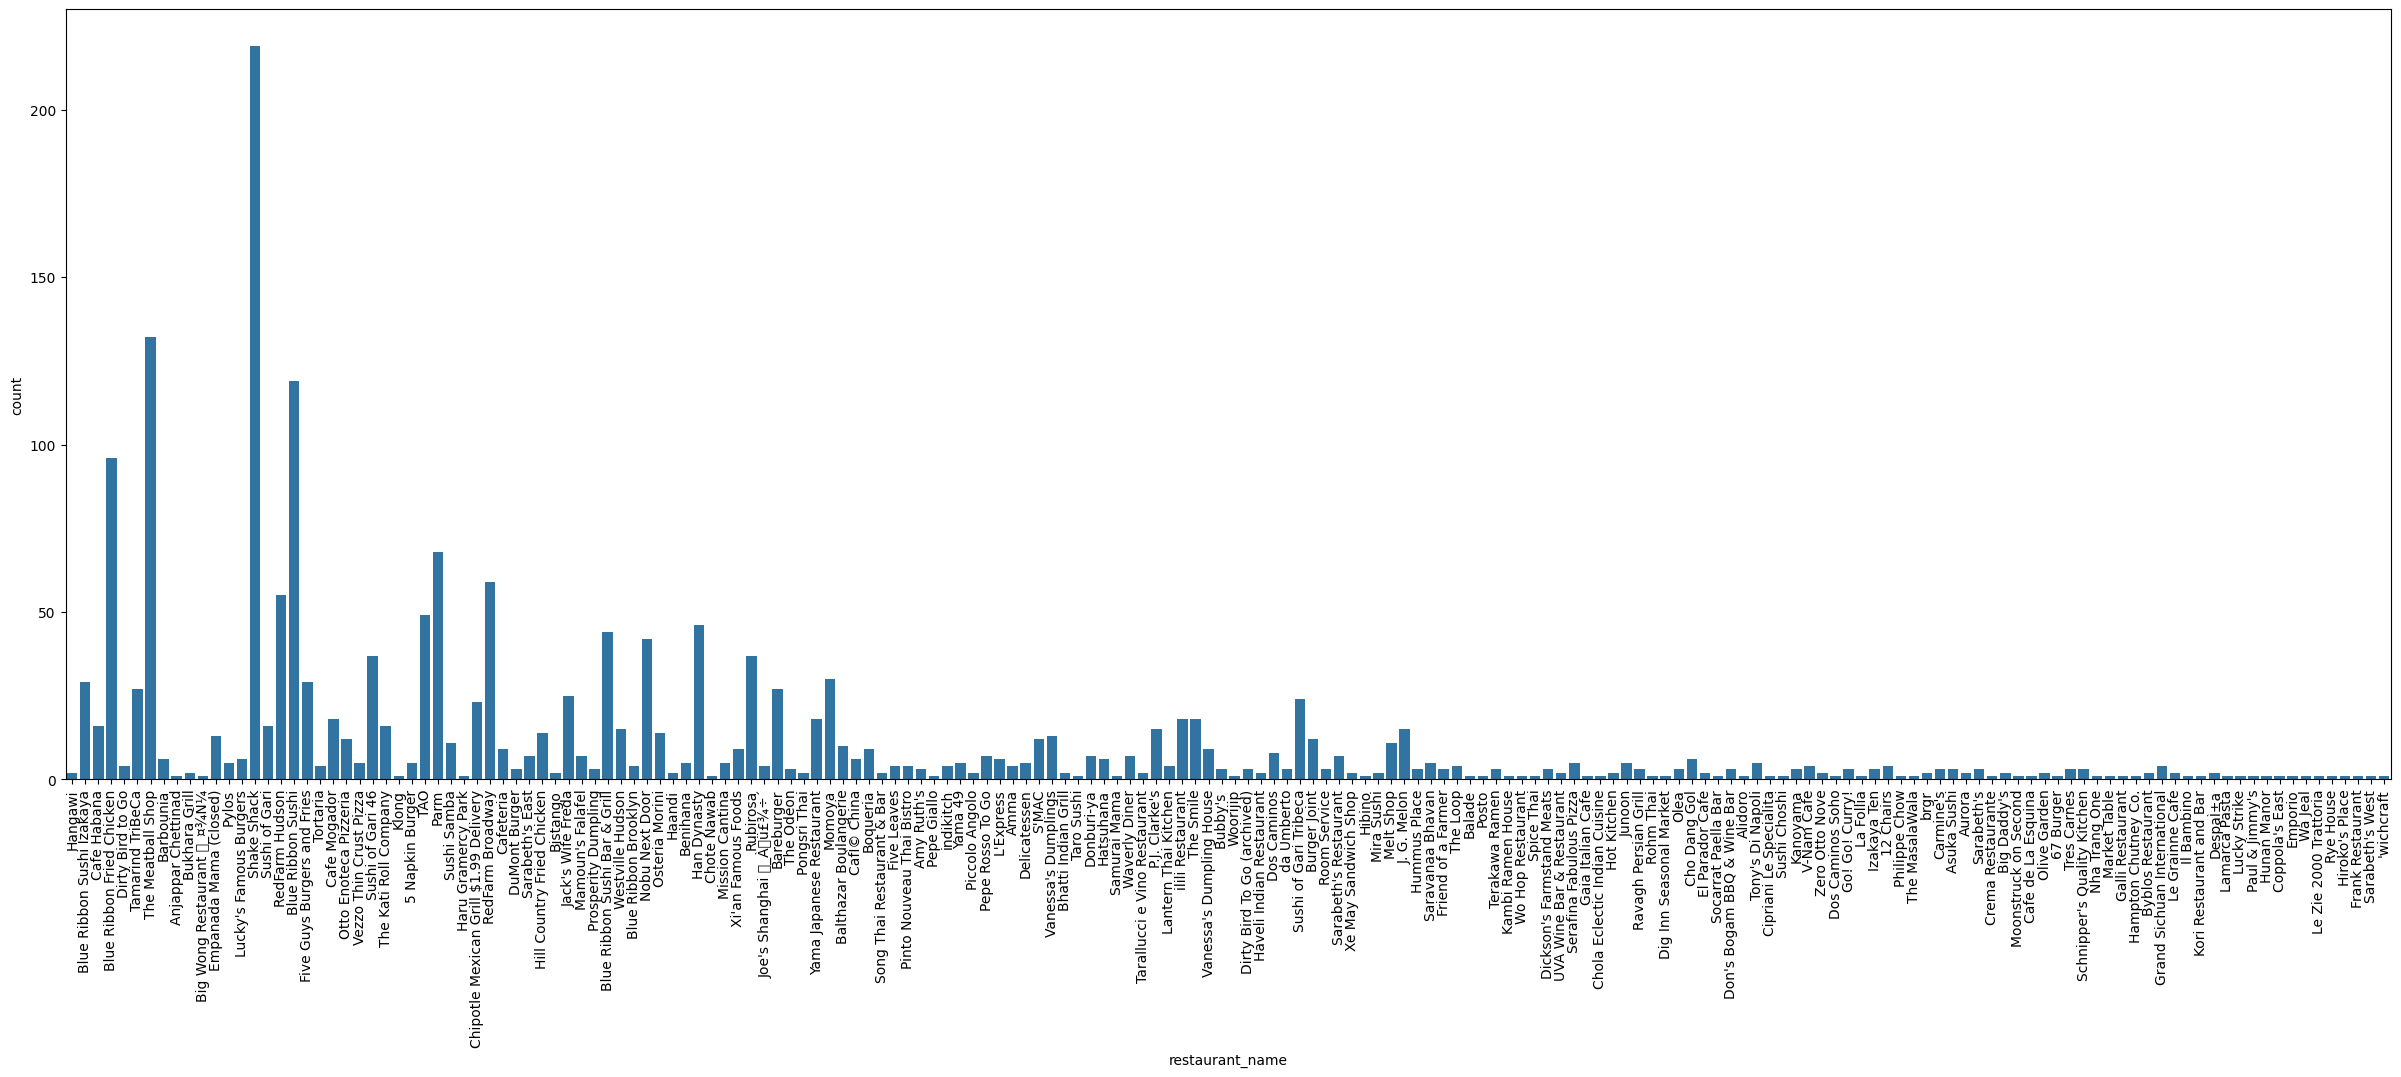

In [304]:
#This plots the frequency of orders from each restaurant
plt.figure(figsize=(30,10));
sns.countplot(data = food, x = 'restaurant_name');
plt.xticks(rotation = 90);
plt.show();

####Observations:
The volume of restaurants still makes any sort of conclusions difficult.  The only thing to be noted is that even the most popular restaurants typically have more than double the number of orders.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [305]:
#pulls out the top five most commonly occuring restaurant names
top_five = food['restaurant_name'].value_counts().head()
print(top_five)
print()

#same as above but in proportion
top_five_norm = food['restaurant_name'].value_counts(normalize=True).head()
print(top_five_norm)
print()


## Code below pulls the type of cuisine of each of the top five restaurants.
# Get the names of the top 5 restaurants
top_five_names = food['restaurant_name'].value_counts().head(5).index

# Filter the dataframe for those names and select the cuisine column
top_five_cuisine = food[food['restaurant_name'].isin(top_five_names)][['restaurant_name', 'cuisine_type']].drop_duplicates()

print(top_five_cuisine)

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

restaurant_name
Shake Shack                 0.115
The Meatball Shop           0.070
Blue Ribbon Sushi           0.063
Blue Ribbon Fried Chicken   0.051
Parm                        0.036
Name: proportion, dtype: float64

               restaurant_name cuisine_type
3    Blue Ribbon Fried Chicken     American
6            The Meatball Shop      Italian
15                 Shake Shack     American
19           Blue Ribbon Sushi     Japanese
34                        Parm      Italian
123          The Meatball Shop     American


#### Observations:
Shake Shack is the most popular restaurant, with 219 orders (11.5% of all orders).  The next most common is The Meatball Shop with 132 orders, Blue Ribbon Sushi with 119, Blue Ribbon Fried Chicken with 96, and Parm with 68.  Interestingly, when I pulled the cuisine type for each of these 5 restaurants, there is a discrepancy in how The Meatball shop is classified.  Sometime it is marked as American Cuisine and othertimes as Italian Cuisine.  This might be worth investigating further to ensure that we are not accidently conflating two distinct restaurants with the same name.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

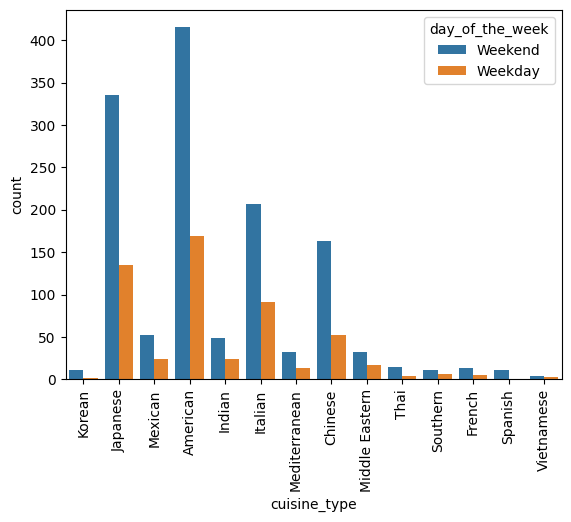

Count: cuisine_type
American         0.307
Japanese         0.248
Italian          0.153
Chinese          0.121
Mexican          0.039
Indian           0.036
Middle Eastern   0.024
Mediterranean    0.024
Thai             0.011
French           0.010
Korean           0.008
Southern         0.008
Spanish          0.008
Vietnamese       0.003
Name: proportion, dtype: float64


In [306]:
# Plot cuisines sorted by do of the week
sns.countplot(data = food, x = 'cuisine_type', hue = 'day_of_the_week');
plt.xticks(rotation = 90);
plt.show();

#Tabulates the proportion of cuisines types for the weekend orders
most_pop_weekend = food[food['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts(normalize=True)
print(f"Count: {most_pop_weekend}")

#### Observations:
American style food is the most popular choic on weekends with 415 orders (or 30.7% of all orders).

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [307]:
# uses the number of rows in the dataframe to calculate proportion
high_cost = food[food['cost_of_the_order'] > 20].shape[0] / food.shape[0] *100
print(f"Percentage over $20: {high_cost:.2f}%")

Percentage over $20: 29.24%


In [308]:
#this pulls out the 5 most popular restaurants for orders over $20
high_cost_df = food[food['cost_of_the_order'] > 20]
exp_rest = high_cost_df['restaurant_name'].value_counts().head()
exp_rest

,count
restaurant_name,
Shake Shack,65
The Meatball Shop,37
Blue Ribbon Fried Chicken,34
Blue Ribbon Sushi,28
Parm,20


#### Observations:
A little less than 1/3 orders cost more than \$20.  Specifically, 29.24% of all orders were over \$20.  Interestingly, the five most popular restaurants overall were _also_ the five most popular restaurants with orders over \$20.  This indicates that these restaurants are popular for both smaller and larger order sizes.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [309]:
# calculate mean, std dev and 95% interval for order delivery time
mean_del_time = food['delivery_time'].mean()
sd_del_time = food['delivery_time'].std()
int_low = mean_del_time - 2*sd_del_time
int_high = mean_del_time + 2*sd_del_time
print(f"Mean delivery time: {mean_del_time:.2f} minutes with a standard deviation of {sd_del_time: .3f} minutes.")
print(f"The 95% interval for the data is between {int_low:.2f} and {int_high:.2f} minutes.")

Mean delivery time: 24.16 minutes with a standard deviation of  4.973 minutes.
The 95% interval for the data is between 14.22 and 34.11 minutes.


#### Observations:
The mean delivery time is 24.16 minutes with a standard deviation of 4.973 minutes.  This suggests that approximately 95% of the orders are delivered in between 14.22 and 34.11 minutes, assuming the distribution is approximatly normal (as discussed above).

### **Question 11:** The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [310]:
# This pulls the top five most commonly found customer id numbers
top_five_cust = food['customer_id'].value_counts().head()
print(top_five_cust)

customer_id
52832     13
47440     10
83287      9
250494     8
259341     7
Name: count, dtype: int64


#### Observations:
In a data set of 1,898 customers, there were surprising few repeat customers.  However, the time frame of data colledtion is unknown (although it is presumably at least a week due to the presence of weekday and weekend data).  Customer #52832 ordered from the company 13 times, customer #47440 ordered 10 times, customer #83287 ordered 9 times, customer #250494 ordered 8 times, and customer #259341 ordered 7 times during the time the data was collected.

## Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset and provide observations. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


                       cost_of_the_order  food_preparation_time  delivery_time
cost_of_the_order                  1.000                  0.042         -0.030
food_preparation_time              0.042                  1.000          0.011
delivery_time                     -0.030                  0.011          1.000


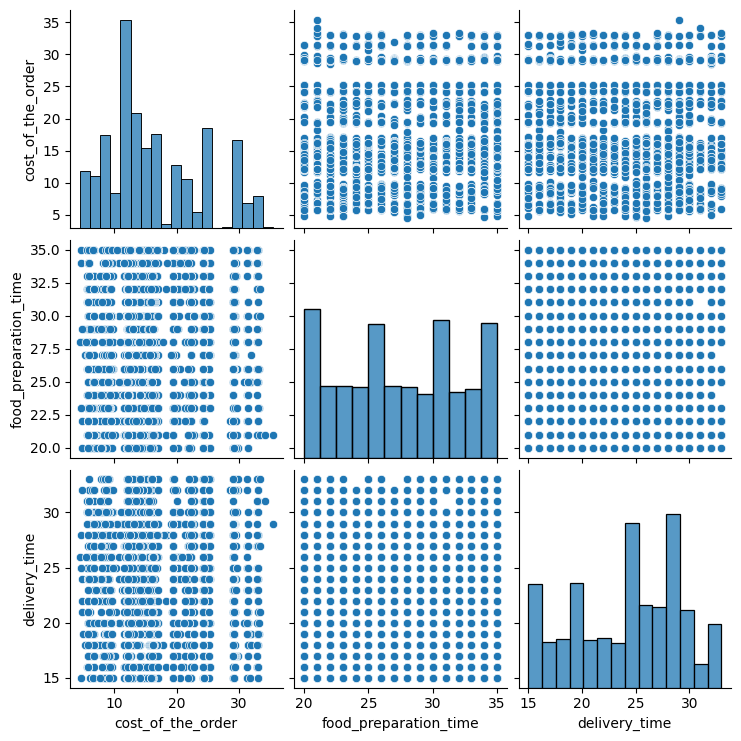

In [311]:
# Drop to only the meaningful numeric values then print all the scatterplots at once
num_vars = ['cost_of_the_order', 'food_preparation_time', 'delivery_time']
sns.pairplot(food[num_vars]);
num_corr = food[num_vars].corr()
print(num_corr)


####Observations:
There is no correlation at all between any of the numeric variables.  In some sense, this is good news since the cost of the order in no way affect the prep time or delivery time of the food.

In [312]:
# Looking at various numeric summaries based on the top five most popular restaurants
top_five_list = top_five.index.tolist()
print(top_five_list)

top_five_df = food[food['restaurant_name'].isin(top_five_list)]
top_five_df = top_five_df.reset_index(drop=True)
top_five_df.head()

['Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi', 'Blue Ribbon Fried Chicken', 'Parm']


,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477334,106968,Blue Ribbon Fried Chicken,American,29.200,Weekend,3,25,15
1,1477894,157711,The Meatball Shop,Italian,6.070,Weekend,Not given,28,21
2,1476966,129969,Blue Ribbon Fried Chicken,American,24.300,Weekend,5,23,17
3,1477414,66222,Shake Shack,American,16.200,Weekend,5,33,25
4,1477354,67487,Blue Ribbon Sushi,Japanese,16.200,Weekend,4,35,26


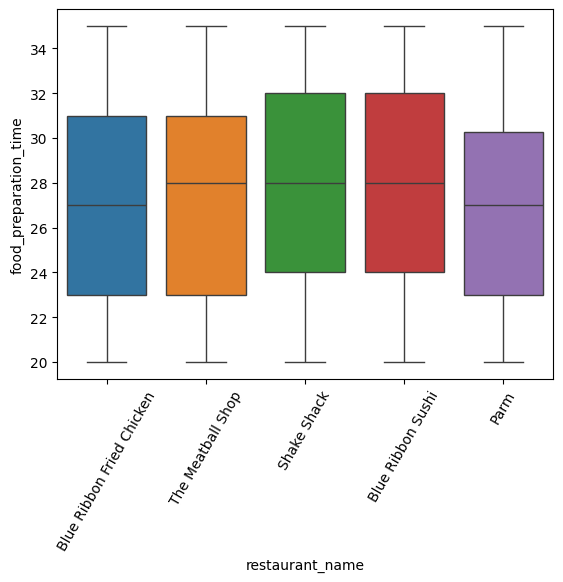

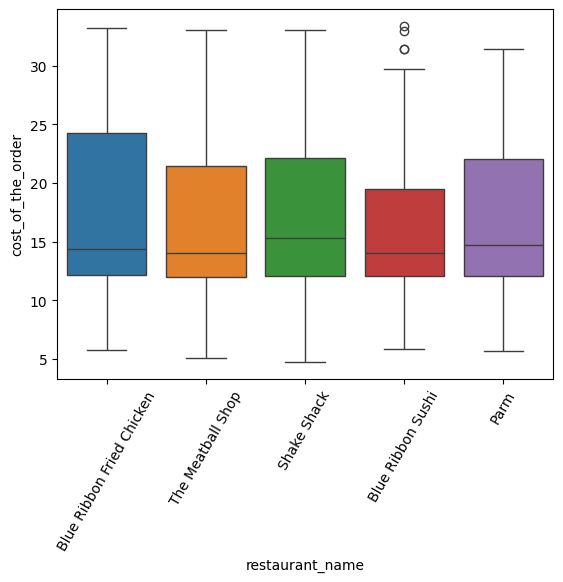

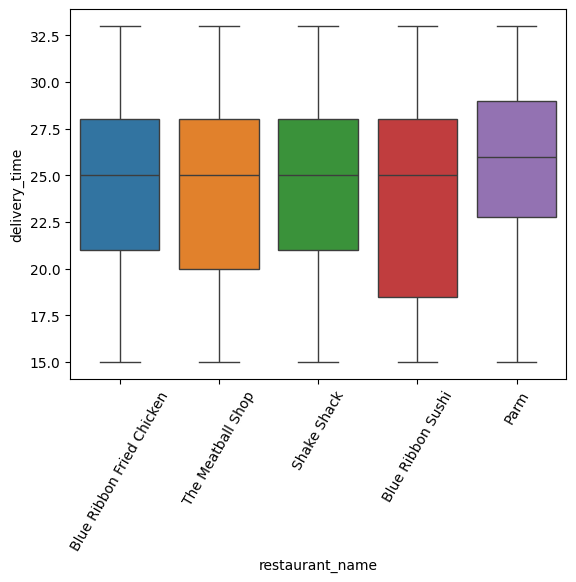

In [313]:
#Generate three boxplots for each of the three numeric variables sorted by the key three categorical variables
# (restaurant names was excluded)
sns.boxplot(data = top_five_df, x = 'restaurant_name', y = 'food_preparation_time', hue="restaurant_name");
plt.xticks(rotation=60)
plt.show()
sns.boxplot(data = top_five_df, x = 'restaurant_name', y = 'cost_of_the_order', hue="restaurant_name");
plt.xticks(rotation=60)
plt.show()
sns.boxplot(data = top_five_df, x = 'restaurant_name', y = 'delivery_time', hue="restaurant_name");
plt.xticks(rotation=60)
plt.show()



####Observations:
Overall, the five most popular restaurants trend very similarly across all three numeric variables.  However, Blue Ribbon Sushi actually appears to be right skewed with a few high end outliers in the cost of order.  As a result, it seems that overall, Blue Ribbon sushi might be slightly cheaper on average than the other five popular restaurants once these outliers are removed.

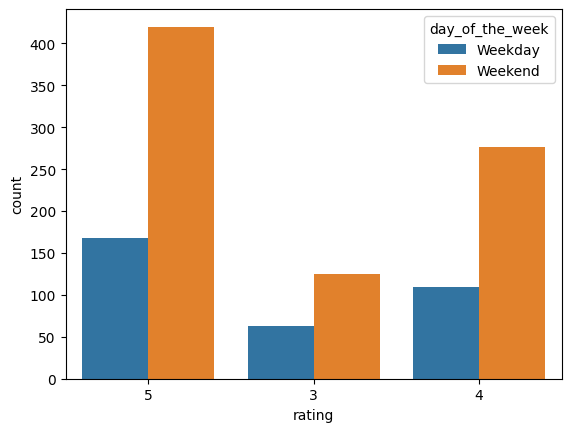

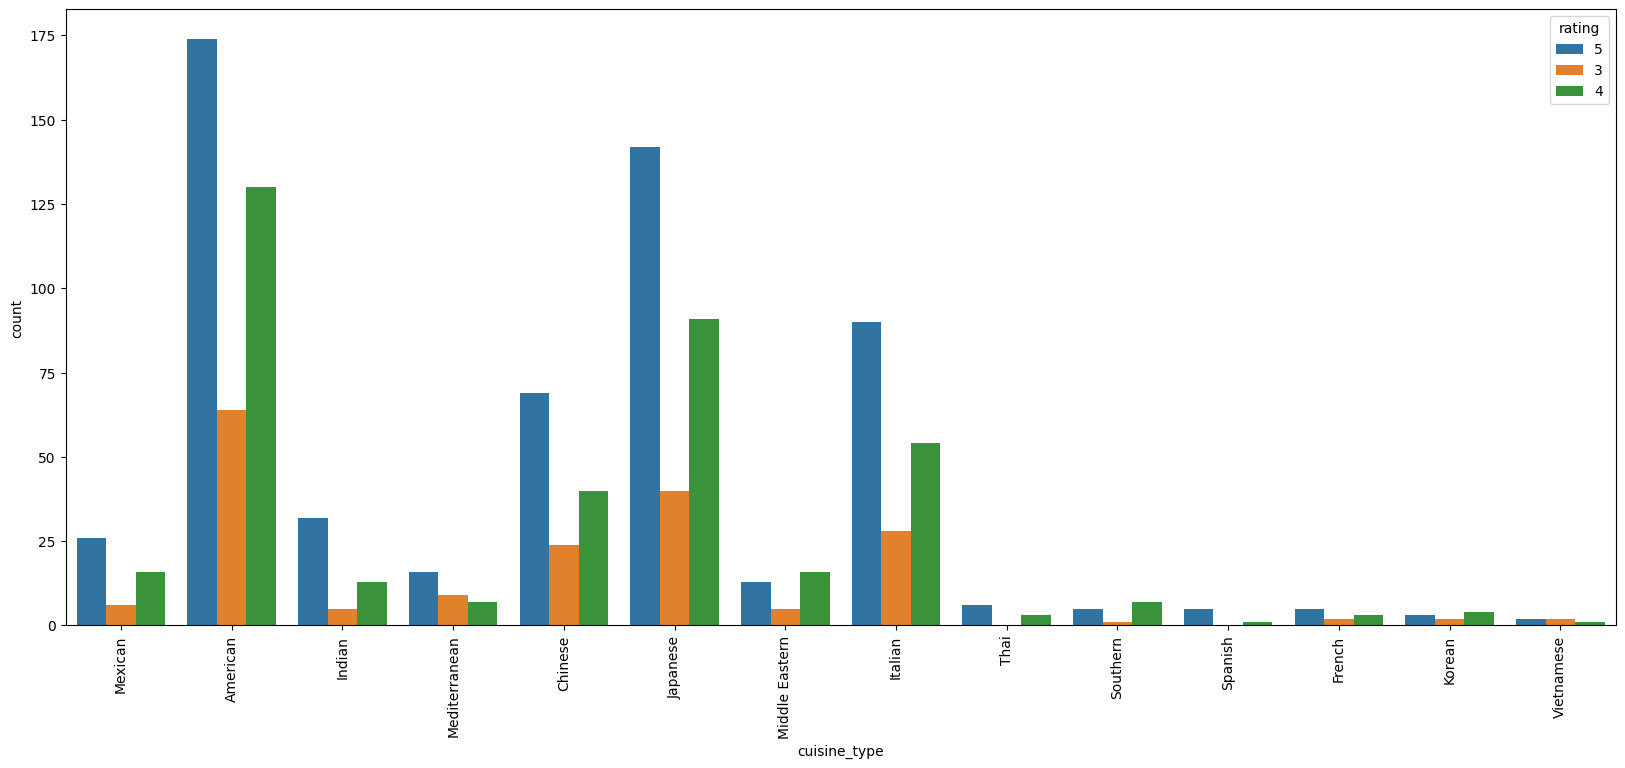

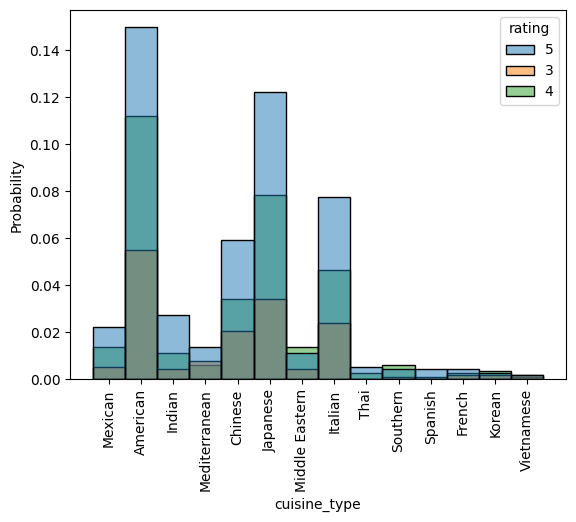

In [314]:
# Dropping out the rows with "Not given" so that I can focus on restaurants that actually got rated
# I chose to drop rather than impute since I did not want it to appear like all restaurants actually received a rating
good_ratings = food.drop(food[food['rating'] == 'Not given'].index).reset_index(drop=True)
good_ratings.head()

#ratings by day of the week
sns.countplot(data = good_ratings, x = 'rating', hue="day_of_the_week");
plt.show()

#ratings by cuisine type
plt.figure(figsize=(20,8));
sns.countplot(data=good_ratings, x = 'cuisine_type', hue = 'rating');
plt.xticks(rotation = 90)
plt.show()

#ratings shown proportionally
sns.histplot(data=good_ratings, x = 'cuisine_type', hue = 'rating', stat = "probability");
plt.xticks(rotation = 90)
plt.show()

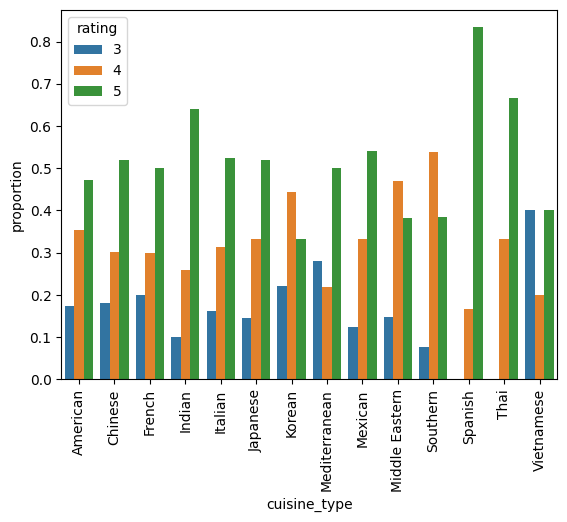

In [315]:
##The frequency distributions above cause some difficulty in making interpretations
##The stacked bar graph above showed relative frequency to the entire data set
##As a result, I used genAI to sort the dataframe in advance and then transform each subcategory
# into a relative frequency using a lambda function
rel_freq = (
    good_ratings
    .groupby(['cuisine_type', 'rating'])
    .size()
    .groupby(level=0)
    .transform(lambda x: x / x.sum())
    .reset_index(name='proportion')
)

#plot of relative frequency of ratings _within_ each group
sns.barplot(data=rel_freq, x='cuisine_type', y='proportion', hue='rating')
plt.xticks(rotation = 90)
plt.show()

####Observations:
The bar graphs above show that ratings may not provide any reliable data on cuisine_type.  Proportionally, each cuisine type shows approximately the same breakdown of 5, 4, and 3 star ratings.  For almost all cuisine types, there is a similar distribution of these ratings. This trend does breakdown a little bit with Vietnamese, Spanish, and Southern restaurants. However, it should be noted that there are so few ratings for these restaurants, that proportions are not reliable.  It is likely that specific restaurants (the restaurant_name variable) is a confounding variable for this graph.  It is likely that different restaurants may have higher or lower ratings than others within the same cuisine.,

In [316]:
#sorting the data frame to see if any patterns emerge when looking only at 3, 4, or 5 star ratings individually
three_star = food.drop(food[food['rating'] != '3'].index).reset_index(drop=True)
four_star = food.drop(food[food['rating'] != '4'].index).reset_index(drop=True)
five_star = food.drop(food[food['rating'] != '5'].index).reset_index(drop=True)

#printing out the value counts for each data frame
print(three_star['restaurant_name'].value_counts())
print(four_star['restaurant_name'].value_counts())
print(five_star['restaurant_name'].value_counts())

#printed the first 10 five star rating counts to see where Parm landed
five_star['restaurant_name'].value_counts().head(10)

restaurant_name
Shake Shack                  23
Blue Ribbon Sushi            16
Blue Ribbon Fried Chicken    11
The Meatball Shop            10
Parm                          9
                             ..
5 Napkin Burger               1
Yama Japanese Restaurant      1
Xi'an Famous Foods            1
Sarabeth's West               1
DuMont Burger                 1
Name: count, Length: 65, dtype: int64
restaurant_name
Shake Shack                    50
Blue Ribbon Sushi              25
The Meatball Shop              21
Blue Ribbon Fried Chicken      21
Parm                           16
                               ..
Schnipper's Quality Kitchen     1
The Odeon                       1
Le Grainne Cafe                 1
Rye House                       1
Frank Restaurant                1
Name: count, Length: 95, dtype: int64
restaurant_name
Shake Shack                  60
The Meatball Shop            53
Blue Ribbon Fried Chicken    32
Blue Ribbon Sushi            32
RedFarm Broadway      

,count
restaurant_name,
Shake Shack,60
The Meatball Shop,53
Blue Ribbon Fried Chicken,32
Blue Ribbon Sushi,32
RedFarm Broadway,18
Blue Ribbon Sushi Bar & Grill,15
RedFarm Hudson,15
Parm,14
TAO,13


###Observations:
Not surprisingly the top five most popular restaurants also appear to be the top restraunts receiving 3, 4, and 5 star reviews with one notable exception:  RedFarm Broadway is the last restaurt in the list of the top five restaurant with five star reviews.  RedFarm Broadway received 18 five star reviews while Parm only received 14 (falling to 8th overall).  This may indicate that Parm, while popular, may not be delivering the best quality or service compared to other popular restaurants.

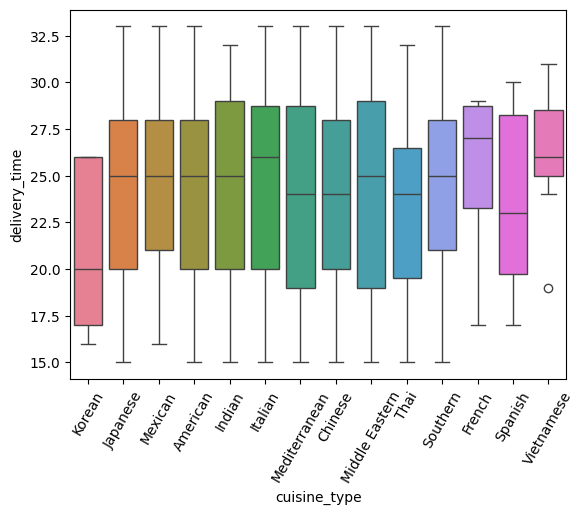

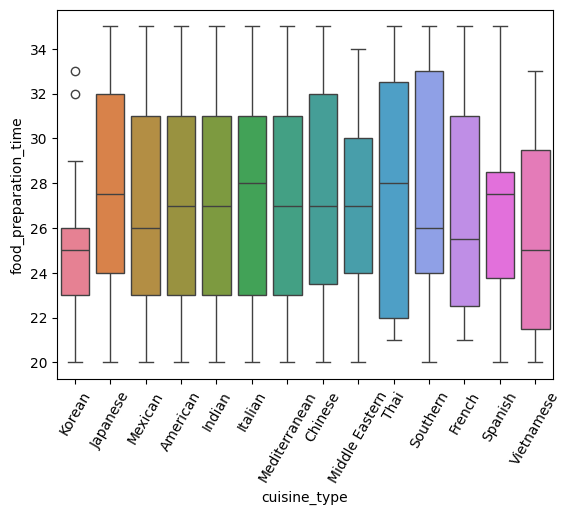

In [317]:
#the box plots below show prep time and delivery time sorted by cuisine type
sns.boxplot(data = food, x = 'cuisine_type', y = 'delivery_time', hue="cuisine_type");
plt.xticks(rotation=60)
plt.show()
sns.boxplot(data = food, x = 'cuisine_type', y = 'food_preparation_time', hue="cuisine_type");
plt.xticks(rotation=60)
plt.show()

####Observations
The mean delivery time and mean prep time based on eaach cuisine time overlap each other significantly.  Korean and Vietnamese foods have the lowest food prep times, but the total counts for these orders is very low.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [318]:
#good_ratings is a variable I created above that dropped all "Not Given" values from the dataset
print(good_ratings['restaurant_name'].value_counts().head(10))

#manually pull the eligible restaurants
eligible_rest = ["Shake Shack", "The Meatball Shop", "Blue Ribbon Sushi", "Blue Ribbon Fried Chicken"]

#copy dataframe (to avoid warnings) and tranform rating variable into an integer type
eligible_df = good_ratings[good_ratings["restaurant_name"].isin(eligible_rest)].copy()
eligible_df['rating'] = eligible_df['rating'].astype(int)

#calculate mean of restaurant ratings
eligible_df.groupby(['restaurant_name'])['rating'].mean()


restaurant_name
Shake Shack                  133
The Meatball Shop             84
Blue Ribbon Sushi             73
Blue Ribbon Fried Chicken     64
RedFarm Broadway              41
Parm                          39
RedFarm Hudson                34
TAO                           28
Rubirosa                      24
Nobu Next Door                23
Name: count, dtype: int64


,rating
restaurant_name,
Blue Ribbon Fried Chicken,4.328
Blue Ribbon Sushi,4.219
Shake Shack,4.278
The Meatball Shop,4.512


#### Observations:
I used a subset of the data called good_ratings.  I chose to drop the rows that had no ratings given for that food order.  While it is possible to impute the missing values with a grouped mean of the data, I felt that this might make it appear that more restaurants received >50 ratings, when in reality, those ratings were imputations.  Thus, for clarity, I only used restaurants that actually received a given value.  There are four restaurants that meet the criteria of having more than 50 ratings:  Blue Ribbon Fried Chicken, Blue Ribbon Sushi, Shake Shack, and The Meatball Shop.  All four of these restaurants also met the criteria for having an average rating of 4 or higher.  Blue Ribbon Fried Chicken had an average of 4.328, Blue Ribbon Sushi had an average rating of 4.219, Shake Shack had an average of 4.278, and The Meatball Shop had an average of 4.512.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [319]:
# for loop to calculate revenue based on dollar amount of the order
# kept big and small orders separate in order to calculat percentage
big_order = 0
small_order = 0
for cost in food['cost_of_the_order']:
  if cost > 20:
    big_order += cost * 0.25
  elif cost > 5:
    small_order += cost * 0.15
  total = big_order + small_order

print(f"The net revenue for the company is ${total:.2f}.")
print(f"Of this revenue, ${big_order:.2f} came from orders greater than $20.")
print(f"Orders between $5 and $20 accounted for ${small_order:.2f} of the revenue.")
print(f"Big order revenue was {big_order / total *100:.2f}% of the revenue.")

# for loop to determine number of orders of less than $5
low_cost = 0
for cost in food['cost_of_the_order']:
  if cost < 5:
    low_cost += 1

print(f"Number of orders below $5: {low_cost}.")

The net revenue for the company is $6166.30.
Of this revenue, $3688.73 came from orders greater than $20.
Orders between $5 and $20 accounted for $2477.58 of the revenue.
Big order revenue was 59.82% of the revenue.
Number of orders below $5: 9.


#### Observations:  
The company's revenue from these orders amounted to $6166.30, of which 59.82% (\$3688.73) came from orders over \$20.  Based on the pricing scheme, some orders (9) from restaurants appear not to have been charged for the service since the order value was \$5 or less.


In [320]:
#Sorting cost of order by time of order to see if there is a difference in orders based on the day
weekend_low, weekend_high, weekday_low, weekday_high = 0, 0, 0, 0

#zip function allows for side-by-side comparison
for cost, day in zip(food['cost_of_the_order'], food['day_of_the_week']):
  if day == 'Weekend':
    if cost > 20:
      weekend_high += 1
    else:
      weekend_low += 1
  if day == "Weekday":
    if cost > 20:
      weekday_high += 1
    else:
      weekday_low += 1

print("Weekend High: ", weekend_high, "   Weekend Low: ", weekend_low)
print("Weekday High: ", weekday_high, "   Weekday Low: ", weekday_low)
print()
print(f"Proportion of high orders on weekends: {weekend_high / (weekend_high + weekend_low):.4f}")
print(f"Proportion of high orders on weekdays: {weekday_high / (weekday_high + weekday_low):.4f}")


Weekend High:  397    Weekend Low:  954
Weekday High:  158    Weekday Low:  389

Proportion of high orders on weekends: 0.2939
Proportion of high orders on weekdays: 0.2888


####Observations
Sub-dividing high and low cost orders by day of the week occurred to me after doing the question above.  However, the proportion of high dollar orders does not appear to be significant impacted by day of the week.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [321]:
# Create a new column for the total time, then calculate that percentage.
food["total_time"] = food["food_preparation_time"] + food["delivery_time"]
food.head()

percentage = food[food["total_time"]>60].shape[0] / food.shape[0] * 100
print(f"The percent of orders that took longer than 60 minutes is {percentage:.2f}%.")

The percent of orders that took longer than 60 minutes is 10.54%.


#### Observations:
The percent of orders that took longer than 60 minutes is 10.54%.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

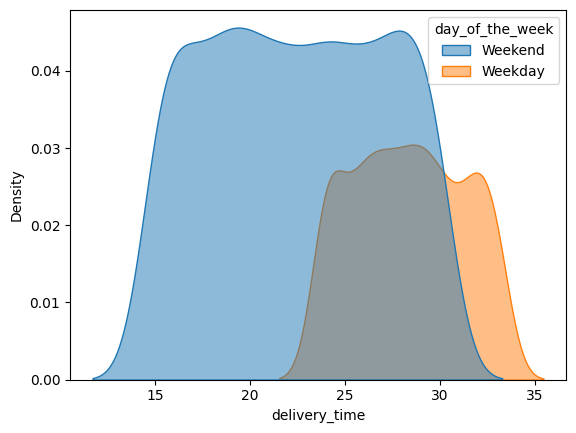

day_of_the_week,Weekday,Weekend
count,547.000,"1,351.000"
mean,55.552,49.907
std,5.568,6.625
min,44.000,35.000
25%,51.000,45.000
50%,55.000,50.000
75%,59.500,55.000
max,68.000,65.000


In [322]:
#I used a shaded density plot to visualize the delivery time between the two day types
sns.kdeplot(data = food, x = 'delivery_time', hue = 'day_of_the_week', fill = True, alpha = 0.5);
plt.show();

#numeric summary of the same data
food.groupby('day_of_the_week')['total_time'].describe().T

#### Observations:
Delivery times on weekdays and weekends are both approximately normally distributed (approaching uniform).  The mean delivery time for weekdays is 55.552 minutes with a standard deviation of 5.568 minutes.  The mean delivery time for weekends is 49.907 minutes with a standard deviation of 6.625 minutes.  Interestingly, although the mean delivery time was lower on the weekends, weekends had the higher variability. Possible reasons for this (that would require further research) are weekend versus weekday road traffic patterns and higher order volumes on weekends (as seen in the univariate analyses above).

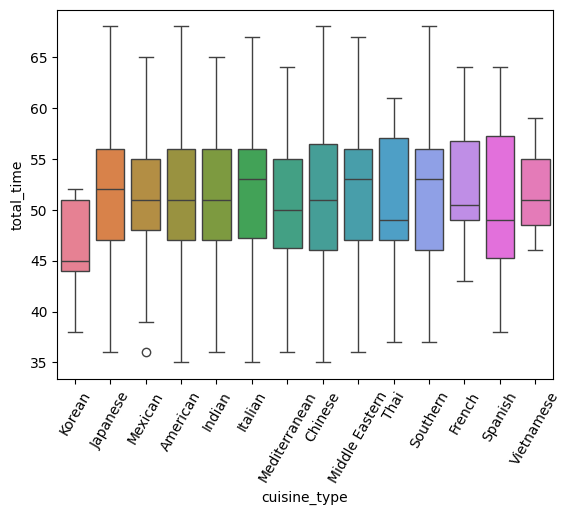

In [323]:
#Repeating an analysis from above now that I have a total time column
# Create a boxplot of total time sorted by cuisine type
sns.boxplot(data = food, x = 'cuisine_type', y = 'total_time', hue="cuisine_type");
plt.xticks(rotation=60)
plt.show()

####Observations
I reran a multivariate analysis above based on the total time and cuisinetype.  Korean food now appears to be faster overall than other cuisine types.  However, the boxplot still overlaps all others signficantly, indicating that this might not be statistically significant.  There is also a single outlier for Mexican food.  However, based on its value, it does not appear to be a data entry error.

# Conclusion and Business Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

## Conclusions

-  Overall, there does not seem to be any link between cost of the order, preparation time, and delivery time.
- Delivery time is not significantly impacted by cuisine type.  This lack of impact is seen even when total time (prep time + delivery time) is taken into account.
- Weekends account for 70% of business.
- The four most popular cuisine types (American, Japanese, Italian, and Chinese) account for 82.6% of orders, while French, Souther, Korean, Spanish, and Vietnamese account for less than 1% of orders.
- 38.8% of orders went unrated (the highest single category). This could lead to skewed data.
- Day of the week (weeend v weekday) does not appear to impact high dollar v low dollar orders.


## Business Recommendations

-  To improve the number of ratings given, consider offering a coupon for every 10 ratings a user gives a delivery.  While this could lead to voluntary-response bias, this is less likely since we will be offering this to existing customers who already use the app.
- To save costs, the company should consider dropping cusine types / restaurants who generate less that 1% of the orders (French, Southern, Korean, Spanish, and Vietnamese).
- While rare, there is lost revenue when a customer places and order of \$5 or less.  The company should consider a flat fee of 15% for **all** orders less than \$20.  
- More research is needed into the weekend / weekday breakdown.  Specifically, data should be collected on hourly orders to determine peak and trough times.  If warranted, the company could consider improving revenue streams by altering is pricing fee from one based solely on order cost to one based on a combination of order cost and the time/day of the order.